In [6]:
pip install ucimlrepo
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 42.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


# data audit 

variables:
|          name |    role |        type  |demographic | description                | units   | missing values|
|---------------|---------|--------------|------------|----------------------------|---------|---------------|
|           Sex | Feature |  Categorical | None       | M, F, and I (infant)       | NaN     |no             |
|        Length | Feature |  Continuous  | None       | Longest shell measurement  | mm      |no             |
|      Diameter | Feature |  Continuous  | None       | Perpendicular to length    | mm      |no             |
|        Height | Feature |  Continuous  | None       | With meat in shell         | mm      |no             |
|  Whole_weight | Feature |  Continuous  | None       | Whole weight               | grams   |no             |
|Shucked_weight | Feature |  Continuous  | None       | Weight of meat             | grams   |no             |
|Viscera_weight | Feature |  Continuous  | None       | Gut weight (after bleeding)| grams   |no             |
|  Shell_weight | Feature |  Continuous  | None       | After being dried          | grams   |no             |
|         Rings | Target  |  Integer     | None       | +1.5 gives the age in years| NaN     |no             |

All of these features will be available to the model at prediction time. 

The target distribution and dataset shape can be seen by running the cell below.  

There are no duplicates among the instances, as can be seen in the cell below.  

Some outliers can be visually detected by examining the histograms of each feature in the cell below, and their data can be read in the listing of the 3 largest/smallest rows for each column. 
For example, feature 236 is the the smallest in all variables but height. All outliers detected seem to be rare, valid cases (e.g. the smallest values are very young specimens), so there is no need to remove them.


(4177, 8)
(4177, 1)
<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
4172    False
4173    False
4174    False
4175    False
4176    False
Length: 4177, dtype: bool>
Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64
    Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  \
236   I   0.075     0.055    0.01         0.002          0.0010   
238   I   0.110     0.090    0.03         0.008          0.0025   
237   I   0.130     0.100    0.03         0.013          0.0045   

     Viscera_weight  Shell_weight  
236          0.0005        0.0015  
238          0.0020        0.0030  
237          0.0030        0.0040  
     Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  \
1428   F   0.815      0.65   0.250         2.255          0.8905   
2334   F   0.800      0.63   0.195         2.526          0.9330   
1209   F   0.780      0.63   0.215         2.657          1.4880   

      Viscera_weight  She

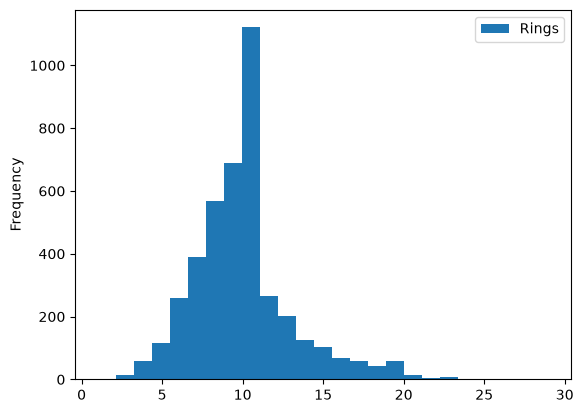

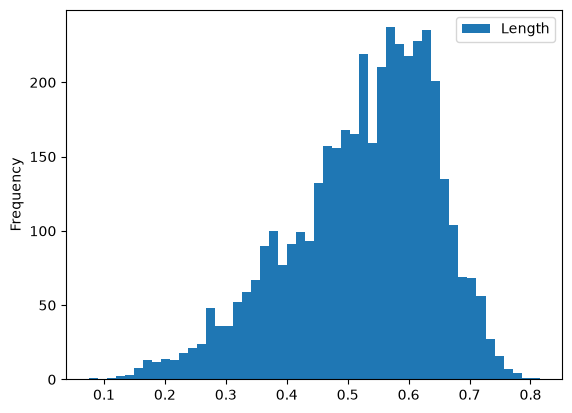

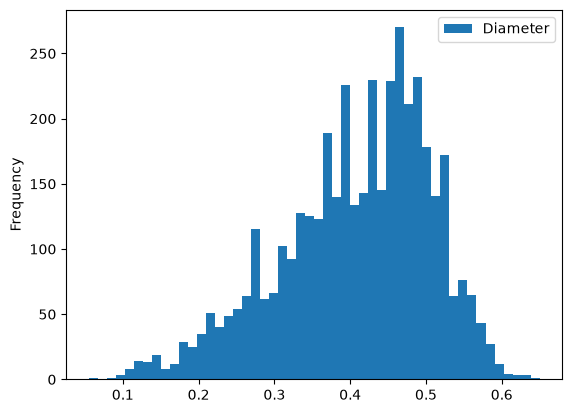

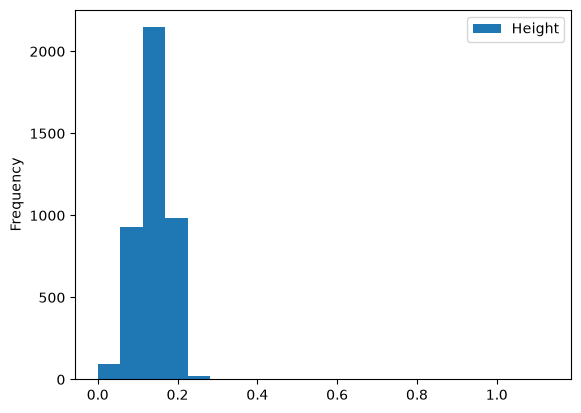

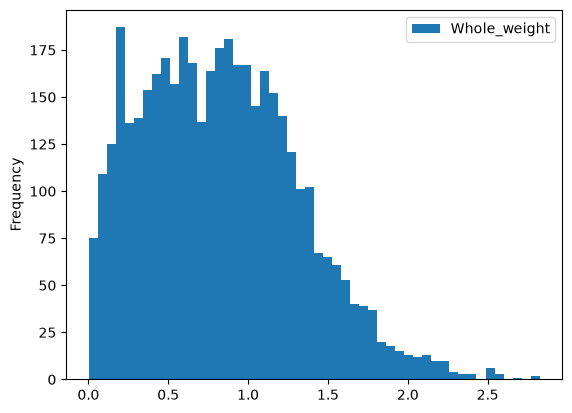

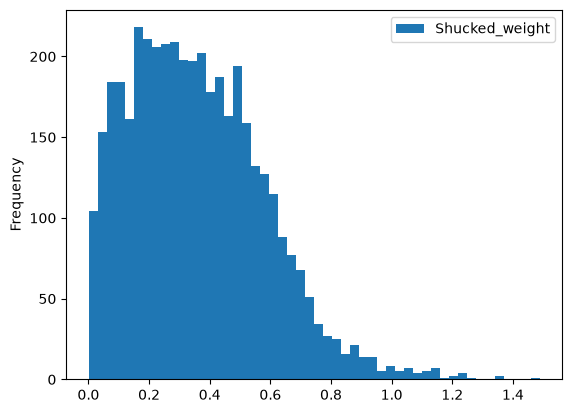

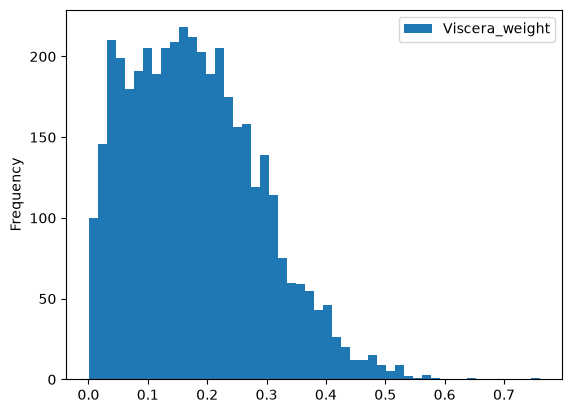

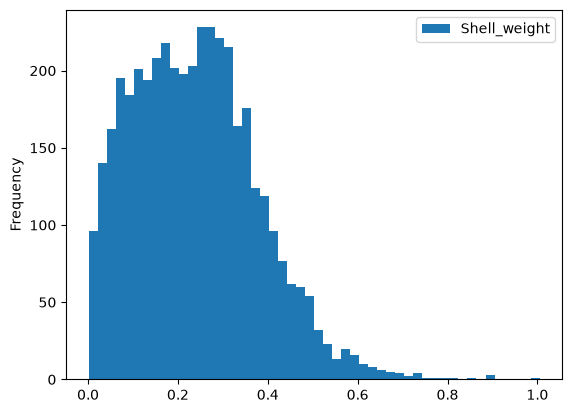

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=1) 
  
# data (as pandas dataframes) 
features = abalone.data.features 
targets = abalone.data.targets 

# print dataset shape 
print(features.shape)
print(targets.shape)

# find duplicates in feature rows
print(features.duplicated().sum)

# print histogram of target distribution
targets.plot.hist(bins=25, column=["Rings"])

# print histogram of feature distribution
features.plot.hist(bins=50, column=["Length"])
features.plot.hist(bins=50, column=["Diameter"])
features.plot.hist(bins=20, column=["Height"])
features.plot.hist(bins=50, column=["Whole_weight"])
features.plot.hist(bins=50, column=["Shucked_weight"])
features.plot.hist(bins=50, column=["Viscera_weight"])
features.plot.hist(bins=50, column=["Shell_weight"])

# distribution of sex values
print(features["Sex"].value_counts())

# print largest and smallest rows of each variable to inspect outliers
print(features.nsmallest(3, "Length"))
print(features.nlargest(3, "Length"))

print(features.nsmallest(3, "Diameter"))
print(features.nlargest(3, "Diameter"))

print(features.nsmallest(3, "Height"))
print(features.nlargest(3, "Height"))

print(features.nsmallest(3, "Whole_weight"))
print(features.nlargest(3, "Whole_weight"))

print(features.nsmallest(3, "Shucked_weight"))
print(features.nlargest(3, "Shucked_weight"))

print(features.nsmallest(3, "Viscera_weight"))
print(features.nlargest(3, "Viscera_weight"))

print(features.nsmallest(3, "Shell_weight"))
print(features.nlargest(3, "Shell_weight"))

print(targets.nsmallest(3, "Rings"))
print(targets.nlargest(3, "Rings"))